# BosonSR Annihilation: Basic Analysis

This notebook runs a compact smoke-analysis of the non-CBC `BosonSR_ann` waveform. 
The GW package wrapper loads the annihilation implementation from `../chris/julia_wf/annihilation.jl`, so the notebook resolves both paths from the parent repository layout.

In [1]:
using Pkg

candidate_dirs = unique([
    abspath(@__DIR__),
    abspath(pwd()),
    joinpath(abspath(@__DIR__), "GW_free_params.jl"),
    joinpath(abspath(pwd()), "GW_free_params.jl"),
])

project_dir_idx = findfirst(dir -> isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "GW.jl")), candidate_dirs)
project_dir_idx === nothing && error("Could not find GW_free_params.jl project directory from pwd=$(pwd()) and @__DIR__=$(@__DIR__)")
project_dir = candidate_dirs[project_dir_idx]
repo_dir = dirname(project_dir)


version =2

if version ==1 

    wrapper_source = joinpath(project_dir, "src", "waveforms", "bosonSR_annihilation.jl")
    annihilation_source = joinpath(repo_dir, "chris", "julia_wf", "annihilation.jl")
elseif version == 2
    wrapper_source = joinpath(project_dir, "src", "waveforms", "bosonSR_annihilation2.jl")
    annihilation_source = joinpath(repo_dir, "chris", "julia_wf", "annihilation2.jl")
else
    error("Unknown version: $version")
end
@assert isfile(wrapper_source) wrapper_source
@assert isfile(annihilation_source) annihilation_source

Pkg.activate(project_dir)

include(joinpath(project_dir, "src", "GW.jl"))
using .GW
using .GW: BosonSR_ann, Pol, Strain, SNR, FisherMatrix, CE1Id_coordinates, CE1Id, ETLS, ETLMR, _available_waveforms
using Plots

default(size=(850, 420), linewidth=2, grid=true)

println("GW project: ", project_dir)
println("GW wrapper: ", wrapper_source)
println("annihilation implementation: ", annihilation_source)

  Activating 

GW project: /home/cherrytree/bosonSR_repo_/GW_free_params.jl

project at `~/bosonSR_repo_/GW_free_params.jl`



GW wrapper: /home/cherrytree/bosonSR_repo_/GW_free_params.jl/src/waveforms/bosonSR_annihilation2.jl
annihilation implementation: /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl


## Waveform and Parameters

`dL` is in Gpc in GWJulia. The value below is intentionally nearby (`1e-6` Gpc = 1 kpc) so the line is easy to inspect.

In [2]:
if version == 1
    model = GW.BosonSR_ann()
elseif version == 2
    model = GW.BosonSR_ann2()
else
    error("Unknown version: $version")
end

M_solar = 10.0
mua = 2.0e-21
intrinsic = (M_solar, mua)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0
phase0 = 0.0

f_line = GW.waveform._ann_line_frequency(M_solar, mua)
fmin = max(2.0, 0.7 * f_line)
fmax = 1.3 * f_line
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", GW._available_waveforms("BosonSR_ann"), " ", GW._available_waveforms("BosonSR_ann2"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("line frequency [Hz]: ", f_line)
println("analysis band [Hz]: ", (first(f), last(f)))
println("Chris function module: ", GW.waveform.ChrisAnnihilation)

available non-CBC model: BosonSR_ann() BosonSR_ann2()
parameter names: (:M_solar, :mua, :dL, :theta, :phi, :iota, :psi, :tcoal, :phiCoal)
line frequency [Hz]: 966.511101258368
analysis band [Hz]: (676.5577708808576, 1256.4644316358783)
Chris function module: Main.GW.waveform.ChrisAnnihilation


In [3]:
if version == 1
    model = GW.BosonSR_ann()
elseif version == 2
    model = GW.BosonSR_ann2()
else
    error("Unknown version: $version")
end

M_solar = 10.0
mua = 2.0e-21
intrinsic = (M_solar, mua)

dL = 1.0e-6
theta = 1.0
phi = 2.0
iota = 0.4
psi = 0.7
tcoal = 0.2
phiCoal = 0.0
phase0 = 0.0

f_line = GW.waveform._ann_line_frequency(M_solar, mua)
fmin = max(2.0, 0.7 * f_line)
fmax = 1.3 * f_line
f = collect(range(fmin, fmax, length=800))

println("available non-CBC model: ", GW._available_waveforms("BosonSR_ann"), " ", GW._available_waveforms("BosonSR_ann2"))
println("parameter names: ", GW.waveform._parameter_names(model))
println("line frequency [Hz]: ", f_line)
println("analysis band [Hz]: ", (first(f), last(f)))
println("Chris function module: ", GW.waveform.ChrisAnnihilation)

available non-CBC model: BosonSR_ann() BosonSR_ann2()
parameter names: (:M_solar, :mua, :dL, :theta, :phi, :iota, :psi, :tcoal, :phiCoal)
line frequency [Hz]: 966.511101258368
analysis band [Hz]: (676.5577708808576, 1256.4644316358783)
Chris function module: Main.GW.waveform.ChrisAnnihilation


## Source-Frame Polarizations

┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121


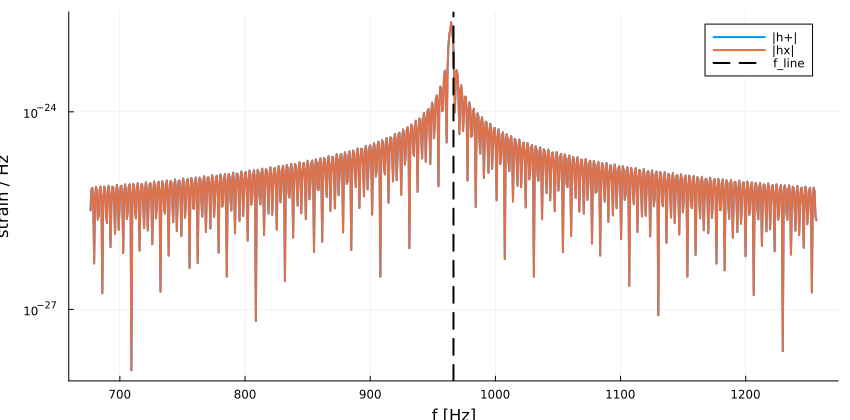

In [6]:
h_plus, h_cross = Pol(model, f, intrinsic, dL, iota, phase0)

plot(f, abs.(h_plus), label="|h+|", xlabel="f [Hz]", ylabel="strain / Hz", yscale=:log10)
plot!(f, abs.(h_cross), label="|hx|")
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## Detector Strain

┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121


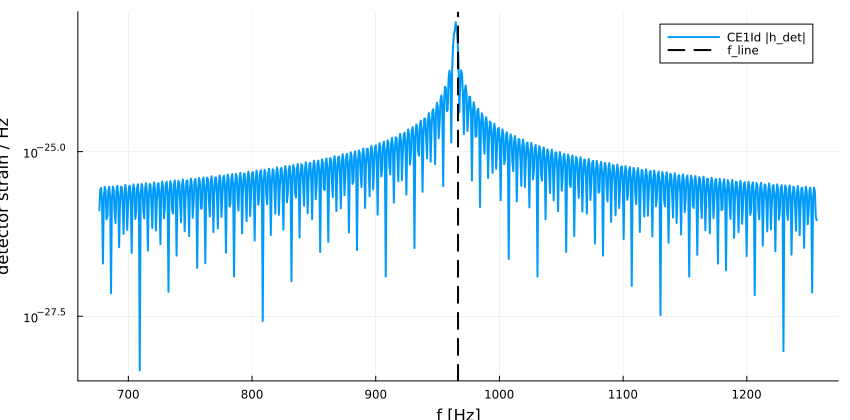

In [7]:
strain_ce = Strain(
    model,
    CE1Id_coordinates,
    f,
    intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal,
    phase0,
)

plot(f, abs.(strain_ce), label="CE1Id |h_det|", xlabel="f [Hz]", ylabel="detector strain / Hz", yscale=:log10)
vline!([f_line], label="f_line", linestyle=:dash, color=:black)

## SNR

In [8]:
network = [ETLS, ETLMR, CE1Id]

# Keep M_solar * mua in a range where the annihilation line remains positive.
M_solar_range = collect(range(1.0, 100.0, length=12))
mua_range = 2.0 .* 10.0 .^ range(-22, -21, length=12)
snr_matrix = fill(NaN, length(M_solar_range), length(mua_range));

In [9]:
for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, mua_j) in enumerate(mua_range)
        intrinsic_ij = (M_solar_i, mua_j)
        f_line_ij = GW.waveform._ann_line_frequency(M_solar_i, mua_j)
        isfinite(f_line_ij) && f_line_ij > 0 || continue

        fmin_ij = max(2.0, 0.7 * f_line_ij)
        fmax_ij = 1.3 * f_line_ij
        fmax_ij > fmin_ij || continue

        try
            snr_matrix[i, j] = SNR(
                model,
                network,
                intrinsic_ij,
                dL,
                theta,
                phi,
                iota,
                psi,
                tcoal;
                fmin=fmin_ij,
                fmax=fmax_ij,
                res=80,
            )
        catch err
            @warn "SNR calculation failed" M_solar_i mua_j exception=(err, catch_backtrace())
        end
    end
end

snr_matrix

┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test


12×12 Matrix{Float64}:
    3.75965e-13      1.77739e-12  …      3.91704e-7      8.46273e-7
    3.08392e-5       0.000155398        49.5976        171.84
    0.00492211       0.0252466       11192.8         21258.7
    0.255928         0.912801            5.77122e5       2.07951e5
    1.13945          9.86703             8.64121e5       8.01708e6
   12.6468          58.3587       …      9.18246e6       2.17215e7
   38.1904         205.47                2.96039e7       8.52099e7
   78.1569         569.331               4.39225e7       4.45602e8
  261.724         2438.39                5.34637e8       4.29334e8
 1513.61          2580.98                5.90249e8       5.18728e8
 3085.17         16318.7          …      6.88193e8       6.20718e8
 7219.62         18862.7                 7.98686e8       7.41131e8

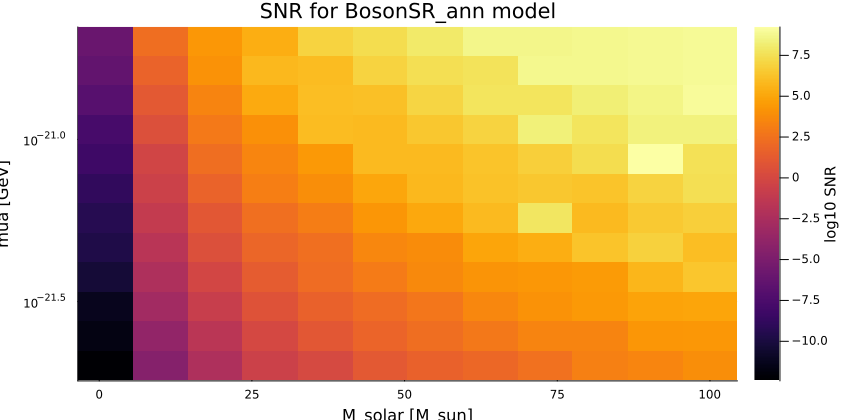

In [10]:
heatmap(
    M_solar_range,
    mua_range,
    log10.(snr_matrix)';
    ylabel="mua [GeV]",
    xlabel="M_solar [M_sun]",
    title="SNR for BosonSR_ann model",
    colorbar_title="log10 SNR",
    yscale=:log10,
)

## Small Fisher Matrix

This is intentionally low resolution. Increase `res` after the smoke run is stable.

┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121


9×9 Matrix{Float64}:
     1.89572e15  -1.67837e39   6.0515e14   …  60227.6            -1.18894e-7
    -1.67837e39   1.48593e63  -5.35814e38        -5.3327e28       1.57117e17
     6.0515e14   -5.35814e38   6.74422e16         6.71219e6       3.31951e-7
    -1.83478e8    1.62456e32  -2.04481e10         5.00014e10     -8.25039e6
    -8.28189e8    7.33299e32  -9.22992e10         1.36326e10     -2.24943e6
     2.55374e8   -2.26114e32   2.84607e10  …     -2.11773e6     349.435
    -1.221e6      1.0811e30   -1.36077e8         -8.20098e8       1.3532e5
 60227.6         -5.3327e28    6.71219e6          2.4771e12      -4.0873e8
    -1.18894e-7   1.57117e17   3.31951e-7        -4.0873e8    67442.2

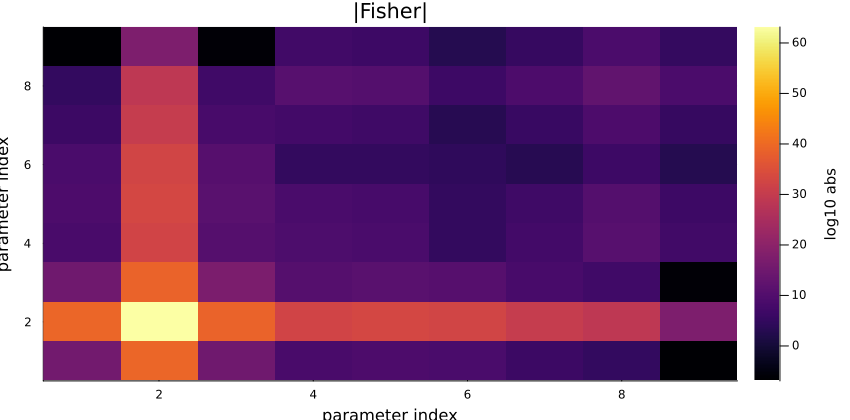

In [16]:
fisher_intrinsic = intrinsic
fisher_f_line = GW.waveform._ann_line_frequency(fisher_intrinsic...)
fisher_fmin = max(2.0, 0.7 * fisher_f_line)
fisher_fmax = 1.3 * fisher_f_line

fisher = FisherMatrix(
    model,
    CE1Id,
    fisher_intrinsic,
    dL,
    theta,
    phi,
    iota,
    psi,
    tcoal,
    phiCoal;
    res=800,
    fmin=fisher_fmin,
    fmax=fisher_fmax,
    rho_thres=nothing,
)

display(fisher)
heatmap(log10.(abs.(fisher)), xlabel="parameter index", ylabel="parameter index", title="|Fisher|", colorbar_title="log10 abs")

## Median SNR over Extrinsic-Parameter Priors

For each point on the intrinsic grid, this section evaluates the network SNR for 20 common Monte Carlo draws from the catalog priors: `cos(theta), cos(iota) ~ Uniform(-1, 1)`, `phi, phiCoal ~ Uniform(0, 2pi)`, `psi ~ Uniform(0, pi)`, and `tcoal ~ Uniform(0, 1)` day. The plotted value is the median over those draws. `phiCoal` is sampled as part of the full extrinsic tuple but is absent from the SNR API because a constant phase does not change the SNR.

In [12]:
using Random, Statistics

n_extrinsic_samples = 20
prior_rng = MersenneTwister(20260715)
extrinsic_samples = [
    (
        theta=acos(2.0 * rand(prior_rng) - 1.0),
        phi=2.0 * pi * rand(prior_rng),
        iota=acos(2.0 * rand(prior_rng) - 1.0),
        psi=pi * rand(prior_rng),
        tcoal=rand(prior_rng),
        phiCoal=2.0 * pi * rand(prior_rng),
    )
    for _ in 1:n_extrinsic_samples
]

function network_snr_from_polabs(model, network, intrinsic, dL, sample, pol_abs; fmin, fmax, res)
    detector_snrs = [
        SNR(
            model, detector, intrinsic, dL, sample.theta, sample.phi, sample.iota, sample.psi, sample.tcoal;
            fmin=fmin, fmax=fmax, res=res, ampl_precomputation=pol_abs,
        )
        for detector in network
    ]
    return sqrt(sum(abs2, detector_snrs))
end

network_snr_from_polabs (generic function with 1 method)

In [13]:
median_snr_matrix = fill(NaN, length(M_solar_range), length(mua_range))
prior_res = 80

for (i, M_solar_i) in enumerate(M_solar_range)
    for (j, mua_j) in enumerate(mua_range)
        intrinsic_ij = (M_solar_i, mua_j)
        f_line_ij = GW.waveform._ann_line_frequency(M_solar_i, mua_j)
        isfinite(f_line_ij) && f_line_ij > 0 || continue

        fmin_ij = max(2.0, 0.7 * f_line_ij)
        fmax_ij = 1.3 * f_line_ij
        fcut_ij = min(GW.waveform._fcut(model, intrinsic_ij...), fmax_ij)
        fcut_ij > fmin_ij || continue
        fgrid_ij = 10.0 .^ range(log10(fmin_ij), log10(fcut_ij), length=prior_res)

        sampled_snrs = Float64[]
        for sample in extrinsic_samples
            try
                pol_abs = GW.PolAbs(model, fgrid_ij, intrinsic_ij, dL, sample.iota)
                push!(sampled_snrs, network_snr_from_polabs(
                    model, network, intrinsic_ij, dL, sample, pol_abs;
                    fmin=fmin_ij, fmax=fmax_ij, res=prior_res,
                ))
            catch err
                @warn "Sampled SNR calculation failed" M_solar_i mua_j exception=(err, catch_backtrace())
            end
        end

        finite_snrs = filter(isfinite, sampled_snrs)
        isempty(finite_snrs) || (median_snr_matrix[i, j] = median(finite_snrs))
    end
end

median_snr_matrix

┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test
└ @ Main.GW.waveform.ChrisAnnihilation2 /home/cherrytree/bosonSR_repo_/chris/julia_wf/annihilation2.jl:121
┌ Warning: test


12×12 Matrix{Float64}:
    1.99481e-13     9.2453e-13  …     1.97505e-7      4.30502e-7
    1.63622e-5      8.08304e-5       25.0069         87.4072
    0.00261179      0.0131341      5642.3         10810.7
    0.135776        0.474894          2.90839e5       1.05681e5
    0.604494        5.13324           4.35207e5       4.07239e6
    6.7103         30.361       …     4.62158e6       1.1024e7
   20.2595        106.894             1.48881e7       4.3197e7
   41.4649        296.2               2.20621e7       2.25588e8
  138.855        1268.77              2.68292e8       2.1697e8
  803.177        1342.62              2.95771e8       2.61569e8
 1637.11         8491.73        …     3.44285e8       3.12169e8
 3831.31         9815.62              3.98822e8       3.71572e8

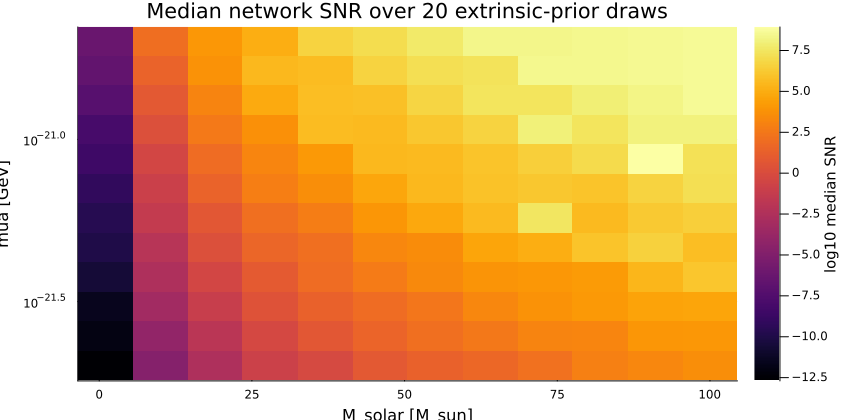

In [14]:
heatmap(
    M_solar_range, mua_range, log10.(median_snr_matrix)';
    ylabel="mua [GeV]", xlabel="M_solar [M_sun]",
    title="Median network SNR over $(n_extrinsic_samples) extrinsic-prior draws",
    colorbar_title="log10 median SNR", yscale=:log10,
)